<a href="https://colab.research.google.com/github/jsarroyo91-ops/Aprendizaje-Autom-tico/blob/main/LDA-QDA/Comparacion_LDA_QDA_Wine_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparación de LDA y QDA con el Wine Dataset

**Objetivo:** desarrollar y comparar modelos de **Análisis Discriminante Lineal (LDA)** y **Análisis Discriminante Cuadrático (QDA)** utilizando el conjunto de datos Wine disponible en `scikit-learn`.

El cuaderno emplea el dataset **sin tratamiento previo**, es decir, sin imputación, eliminación de valores atípicos, balanceo, selección de variables, reducción de dimensionalidad ni estandarización. Esta decisión permite observar el comportamiento natural de ambos modelos sobre las variables originales.

**Contenido del cuaderno**

1. Descripción del conjunto de datos.
2. Exploración de los datos.
3. Visualización.
4. Preparación de los datos.
5. Implementación de LDA.
6. Implementación de QDA.
7. Comparación de modelos.
8. Fronteras de decisión.
9. Conclusiones.


## Importación de librerías

In [ ]:
# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librerías para visualización
import matplotlib.pyplot as plt

# Dataset y herramientas de modelado
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# Métricas de evaluación
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Medición opcional del tiempo de entrenamiento
from time import perf_counter

# Configuración de visualización de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

print('Librerías importadas correctamente.')


Librerías importadas correctamente.


## 1. Descripción del conjunto de datos

El **Wine Dataset** fue construido a partir de análisis químicos realizados a vinos producidos en una misma región de Italia, pero provenientes de tres cultivares diferentes. En `scikit-learn` se distribuye como un conjunto de datos clásico para problemas de clasificación multiclase.

- **Origen:** base Wine de UCI Machine Learning Repository, incorporada en `scikit-learn`.
- **Número de observaciones:** 178 vinos.
- **Variables predictoras:** 13 variables numéricas obtenidas mediante análisis químico.
- **Variable objetivo:** cultivar o clase del vino.
- **Cantidad de clases:** 3 (`class_0`, `class_1` y `class_2`).

Las variables predictoras son: alcohol, ácido málico, cenizas, alcalinidad de las cenizas, magnesio, fenoles totales, flavonoides, fenoles no flavonoides, proantocianinas, intensidad del color, matiz, relación OD280/OD315 y prolina.


In [ ]:
# Cargar el Wine Dataset desde scikit-learn
wine = load_wine()

# Crear un DataFrame con las variables predictoras
X = pd.DataFrame(wine.data, columns=wine.feature_names)

# Crear una Serie con la variable objetivo
y = pd.Series(wine.target, name='target')

# Integrar variables predictoras y objetivo en un solo DataFrame
# Este DataFrame se utiliza únicamente para exploración y visualización.
df = X.copy()
df['target'] = y
df['class_name'] = df['target'].map(dict(enumerate(wine.target_names)))

print('Origen del dataset: Wine Dataset de scikit-learn / UCI')
print('Número de observaciones:', X.shape[0])
print('Número de variables predictoras:', X.shape[1])
print('Variable objetivo: target')
print('Clases:', list(wine.target_names))
print('\nPrimeras cinco observaciones:')
display(df.head())


Origen del dataset: Wine Dataset de scikit-learn / UCI
Número de observaciones: 178
Número de variables predictoras: 13
Variable objetivo: target
Clases: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Primeras cinco observaciones:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


## 2. Exploración de los datos

In [ ]:
# Dimensiones del conjunto completo
print('Dimensiones del DataFrame:', df.shape)
print('Filas:', df.shape[0])
print('Columnas:', df.shape[1])

# Tipos de variables
print('\nTipos de variables:')
display(df.dtypes.to_frame(name='tipo_de_dato'))

# Información general del DataFrame
print('\nInformación general:')
df.info()


Dimensiones del DataFrame: (178, 15)
Filas: 178
Columnas: 15

Tipos de variables:


,tipo_de_dato
alcohol,float64
malic_acid,float64
ash,float64
alcalinity_of_ash,float64
magnesium,float64
total_phenols,float64
flavanoids,float64
nonflavanoid_phenols,float64
proanthocyanins,float64
color_intensity,float64



Información general:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null

In [ ]:
# Conteo de valores faltantes por columna
faltantes = df.isnull().sum().to_frame(name='valores_faltantes')
faltantes['porcentaje'] = (faltantes['valores_faltantes'] / len(df)) * 100

display(faltantes)

print('Total de valores faltantes:', int(df.isnull().sum().sum()))


,valores_faltantes,porcentaje
alcohol,0,0.0
malic_acid,0,0.0
ash,0,0.0
alcalinity_of_ash,0,0.0
magnesium,0,0.0
total_phenols,0,0.0
flavanoids,0,0.0
nonflavanoid_phenols,0,0.0
proanthocyanins,0,0.0
color_intensity,0,0.0


Total de valores faltantes: 0


El conjunto de datos no presenta valores faltantes. Por esta razón, no es necesario aplicar imputación. Todas las variables predictoras son numéricas, mientras que `target` es una variable categórica codificada numéricamente y `class_name` es su representación textual.


In [ ]:
# Estadísticas descriptivas de las variables predictoras
estadisticas = X.describe().T
estadisticas['rango'] = estadisticas['max'] - estadisticas['min']
display(estadisticas)


,count,mean,std,min,25%,50%,75%,max,rango
alcohol,178.0,13.0006,0.8118,11.03,12.3625,13.050,13.6775,14.83,3.80
malic_acid,178.0,2.3363,1.1171,0.74,1.6025,1.865,3.0825,5.80,5.06
ash,178.0,2.3665,0.2743,1.36,2.2100,2.360,2.5575,3.23,1.87
alcalinity_of_ash,178.0,19.4949,3.3396,10.60,17.2000,19.500,21.5000,30.00,19.40
magnesium,178.0,99.7416,14.2825,70.00,88.0000,98.000,107.0000,162.00,92.00
total_phenols,178.0,2.2951,0.6259,0.98,1.7425,2.355,2.8000,3.88,2.90
flavanoids,178.0,2.0293,0.9989,0.34,1.2050,2.135,2.8750,5.08,4.74
nonflavanoid_phenols,178.0,0.3619,0.1245,0.13,0.2700,0.340,0.4375,0.66,0.53
proanthocyanins,178.0,1.5909,0.5724,0.41,1.2500,1.555,1.9500,3.58,3.17
color_intensity,178.0,5.0581,2.3183,1.28,3.2200,4.690,6.2000,13.00,11.72


Las variables se encuentran expresadas en escalas diferentes. Por ejemplo, `proline` presenta valores mucho mayores que `nonflavanoid_phenols`. En este trabajo se conservarán las escalas originales porque se solicitó utilizar el Wine Dataset sin tratamiento. En términos teóricos, LDA y QDA incorporan la estructura de covarianza de los datos; sin embargo, las diferencias de escala pueden afectar la estabilidad numérica en otros conjuntos de datos.


In [ ]:
# Distribución absoluta y relativa de las clases
conteo_clases = df['class_name'].value_counts().reindex(wine.target_names)
porcentaje_clases = (conteo_clases / len(df) * 100).round(2)

distribucion_clases = pd.DataFrame({
    'frecuencia': conteo_clases,
    'porcentaje': porcentaje_clases
})

display(distribucion_clases)


,frecuencia,porcentaje
class_name,,
class_0,59,33.15
class_1,71,39.89
class_2,48,26.97


Las clases no tienen exactamente el mismo tamaño, pero no hay desbalance entre clases. La clase con mayor cantidad de observaciones es `class_1`. Debido a esta diferencia moderada, la partición entrenamiento-prueba se realizará con `stratify=y` para conservar proporciones similares en ambos subconjuntos.


## 3. Visualización de los datos

### 3.1 Histogramas de las variables predictoras

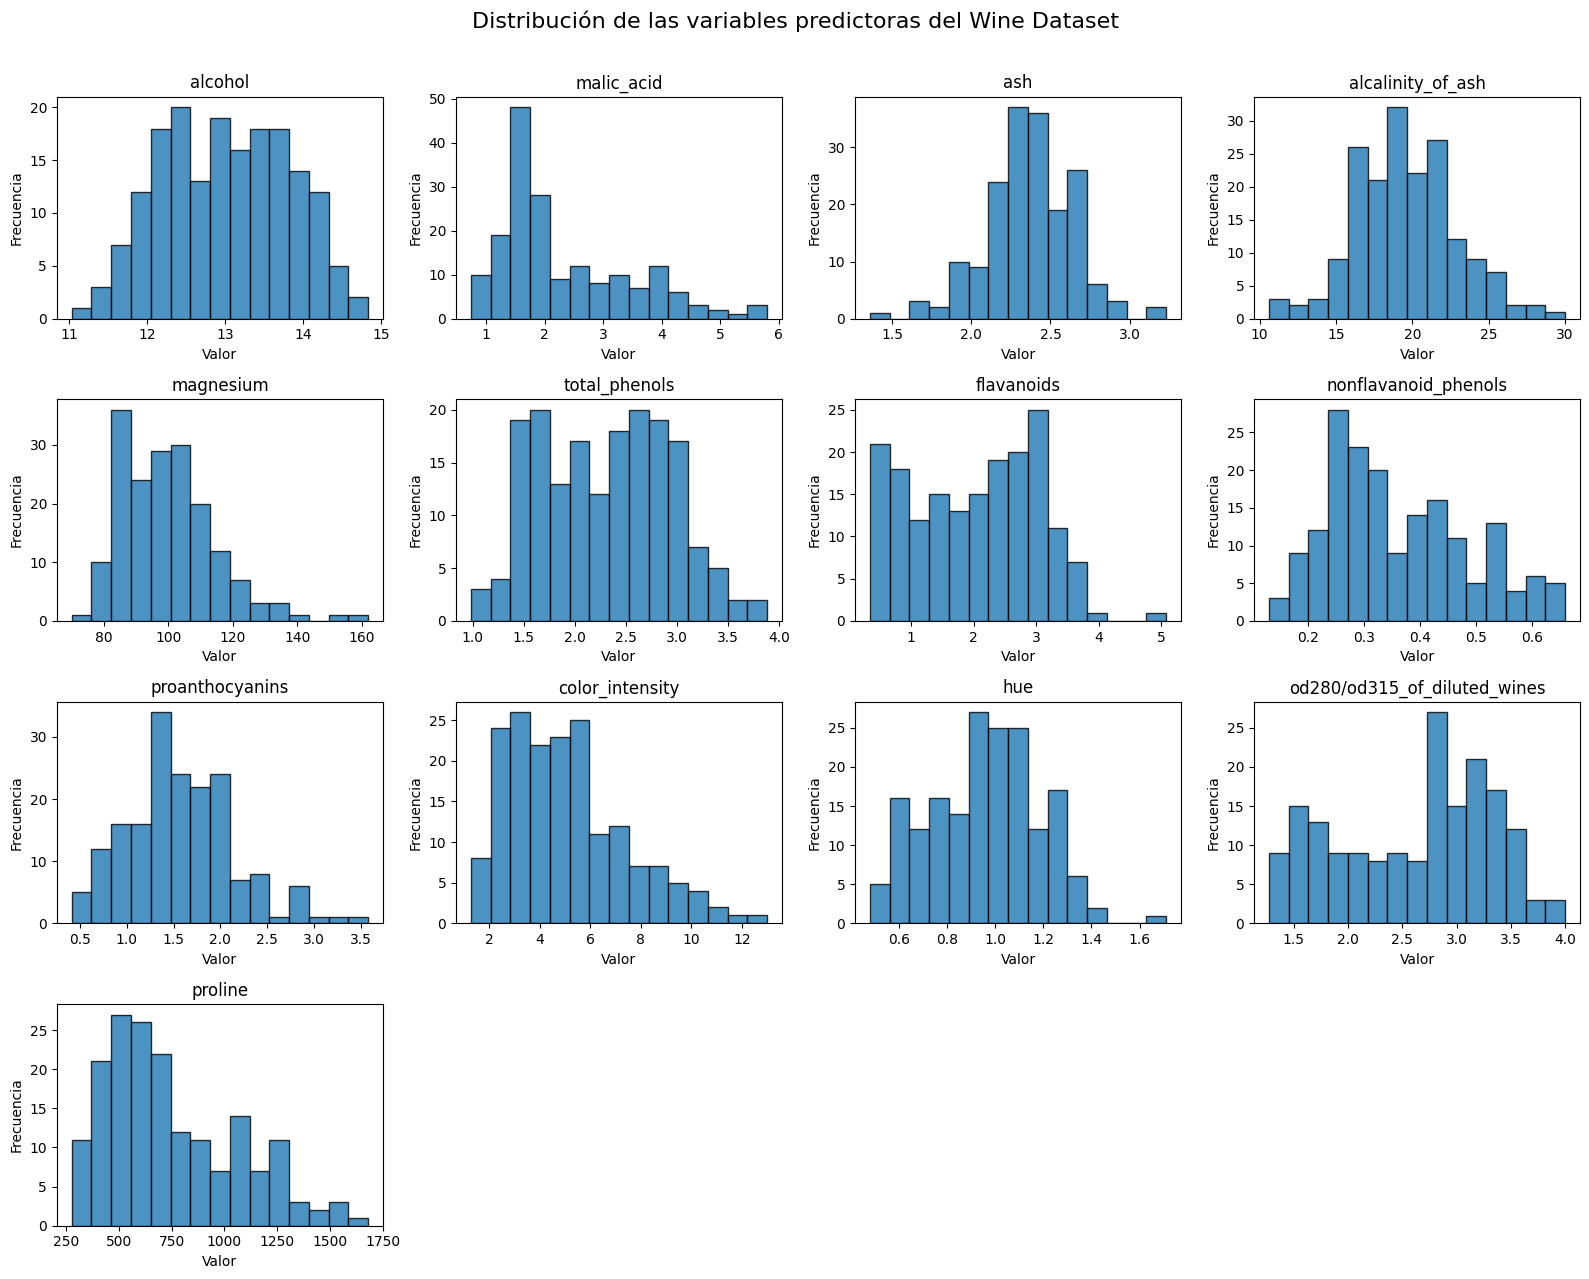

In [ ]:
# Crear una cuadrícula de histogramas para las 13 variables predictoras
fig, axes = plt.subplots(4, 4, figsize=(16, 13))
axes = axes.flatten()

for i, columna in enumerate(X.columns):
    axes[i].hist(X[columna], bins=15, edgecolor='black', alpha=0.8)
    axes[i].set_title(columna)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')

# Ocultar los espacios de la cuadrícula que no se utilizan
for j in range(len(X.columns), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribución de las variables predictoras del Wine Dataset', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


**Interpretación:** los histogramas muestran que las variables no comparten una misma forma de distribución. Algunas presentan asimetría o concentraciones diferenciadas, mientras que otras se aproximan más a una distribución unimodal. LDA y QDA suponen normalidad multivariada dentro de cada clase, por lo que estos gráficos constituyen una primera aproximación; sin embargo, la normalidad multivariada no puede concluirse únicamente mediante histogramas marginales.


### 3.2 Diagrama de dispersión por clase

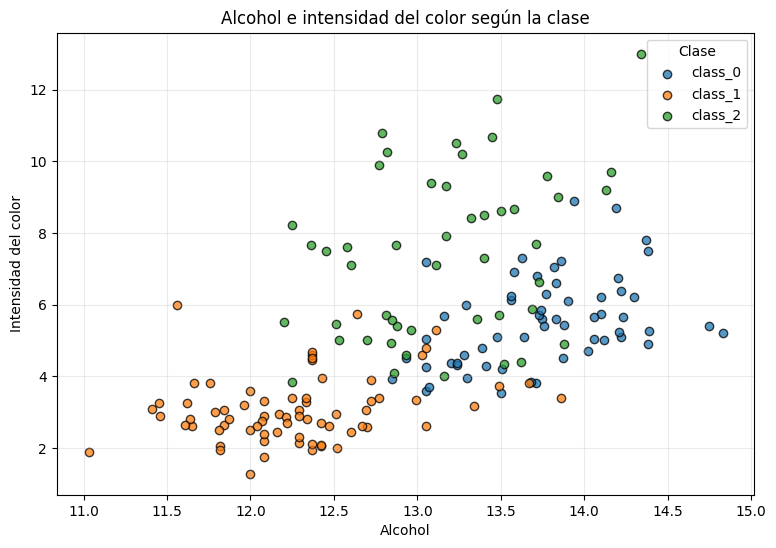

In [ ]:
# Diagrama de dispersión entre alcohol e intensidad del color
fig, ax = plt.subplots(figsize=(9, 6))

for clase, nombre in enumerate(wine.target_names):
    mascara = y == clase
    ax.scatter(
        X.loc[mascara, 'alcohol'],
        X.loc[mascara, 'color_intensity'],
        label=nombre,
        alpha=0.75,
        edgecolors='black'
    )

ax.set_title('Alcohol e intensidad del color según la clase')
ax.set_xlabel('Alcohol')
ax.set_ylabel('Intensidad del color')
ax.legend(title='Clase')
ax.grid(alpha=0.25)
plt.show()


**Interpretación:** la combinación de `alcohol` e `intensidad del color` permite observar una separación parcial entre los cultivares. Existen zonas de superposición, por lo que una única frontera recta puede resultar insuficiente en algunos sectores. Esta pareja de variables se utilizará posteriormente para visualizar las fronteras de decisión de LDA y QDA.


### 3.3 Mapa de correlaciones

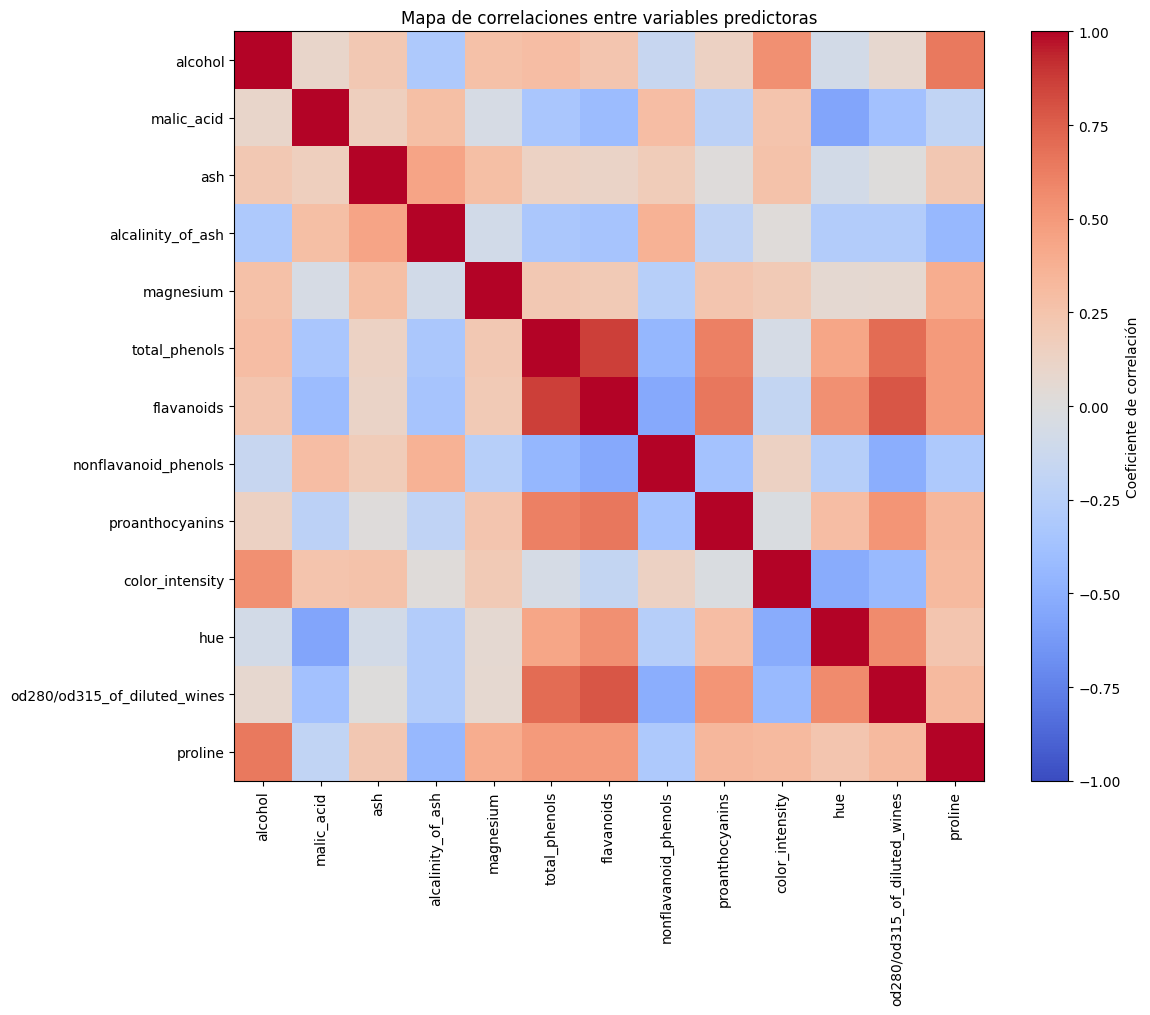

In [ ]:
# Calcular la matriz de correlación de las variables predictoras
correlacion = X.corr()

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(correlacion, cmap='coolwarm', vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(correlacion.columns)))
ax.set_yticks(np.arange(len(correlacion.columns)))
ax.set_xticklabels(correlacion.columns, rotation=90)
ax.set_yticklabels(correlacion.columns)
ax.set_title('Mapa de correlaciones entre variables predictoras')

# Añadir barra de color
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Coeficiente de correlación')

plt.tight_layout()
plt.show()


**Interpretación:** el mapa evidencia relaciones importantes entre algunas variables. Por ejemplo, `total_phenols`, `flavanoids` y `od280/od315_of_diluted_wines` presentan correlaciones positivas considerables. La presencia de correlación no invalida automáticamente LDA o QDA, pero influye en la estimación de las matrices de covarianza y puede generar inestabilidad si existen relaciones casi lineales entre variables.


### 3.4 Boxplots por clase

/tmp/ipykernel_1311/2532749152.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_clase, labels=wine.target_names, patch_artist=True)
/tmp/ipykernel_1311/2532749152.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_clase, labels=wine.target_names, patch_artist=True)
/tmp/ipykernel_1311/2532749152.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(datos_por_clase, labels=wine.target_names, patch_artist=True)
/tmp/ipykernel_1311/2532749152.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.

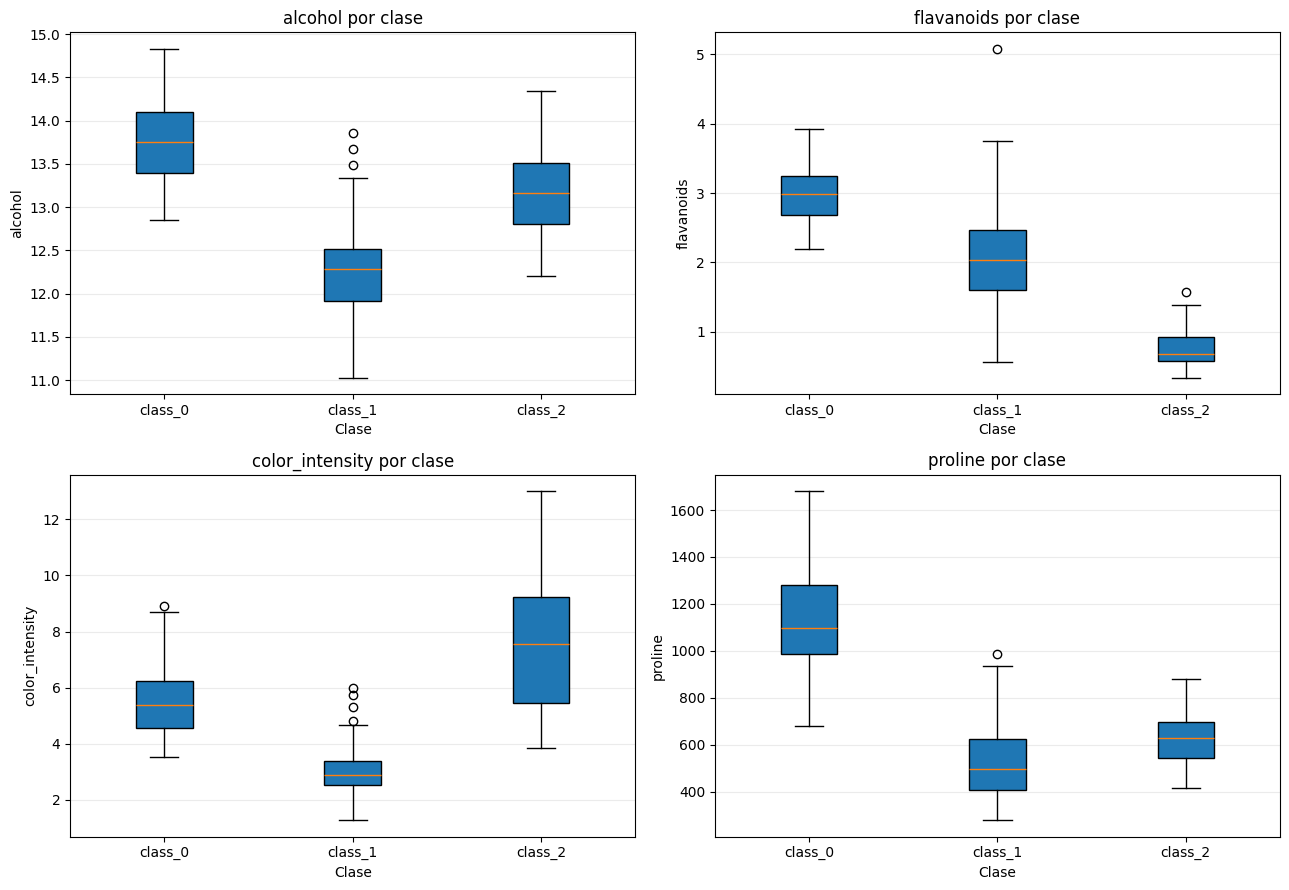

In [ ]:
# Seleccionar cuatro variables para comparar sus distribuciones entre clases
variables_boxplot = ['alcohol', 'flavanoids', 'color_intensity', 'proline']

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, variable in zip(axes, variables_boxplot):
    datos_por_clase = [
        X.loc[y == clase, variable].values
        for clase in range(len(wine.target_names))
    ]
    ax.boxplot(datos_por_clase, labels=wine.target_names, patch_artist=True)
    ax.set_title(f'{variable} por clase')
    ax.set_xlabel('Clase')
    ax.set_ylabel(variable)
    ax.grid(axis='y', alpha=0.25)

plt.tight_layout()
plt.show()


**Interpretación:** los boxplots muestran que varias variables presentan diferencias de localización y dispersión entre las clases. `flavanoids` y `proline`, por ejemplo, ayudan a distinguir cultivares. También se observan amplitudes diferentes entre grupos, lo cual sugiere que la hipótesis de una covarianza común utilizada por LDA podría no cumplirse de manera perfecta y justifica comparar su desempeño con QDA.


## 4. Preparación de los datos

La preparación se limita a separar los datos en entrenamiento y prueba. Se aplican las siguientes decisiones:

- **80 % para entrenamiento y 20 % para prueba.**
- `random_state=42` para que el experimento sea reproducible.
- `stratify=y` para conservar la proporción de las tres clases.
- **No se estandarizan las variables**, debido a la instrucción de trabajar con el dataset sin tratamiento.
- No se imputan valores porque el conjunto no contiene datos faltantes.
- No se eliminan valores atípicos ni se realiza selección de variables.

El conjunto de prueba se mantiene separado durante el entrenamiento y se utiliza exclusivamente para evaluar la capacidad de generalización.


In [ ]:
# Separación estratificada entre entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('Dimensiones de X_train:', X_train.shape)
print('Dimensiones de X_test:', X_test.shape)
print('Dimensiones de y_train:', y_train.shape)
print('Dimensiones de y_test:', y_test.shape)

# Comprobar la proporción de clases en ambos subconjuntos
proporciones = pd.DataFrame({
    'entrenamiento': y_train.value_counts(normalize=True).sort_index(),
    'prueba': y_test.value_counts(normalize=True).sort_index()
})
proporciones.index = wine.target_names
proporciones = (proporciones * 100).round(2)

display(proporciones)


Dimensiones de X_train: (142, 13)
Dimensiones de X_test: (36, 13)
Dimensiones de y_train: (142,)
Dimensiones de y_test: (36,)


,entrenamiento,prueba
class_0,33.10,33.33
class_1,40.14,38.89
class_2,26.76,27.78


## Función auxiliar de evaluación

Para asegurar una comparación homogénea se utilizarán las mismas métricas en ambos modelos. Dado que el problema tiene tres clases, `precision`, `recall` y `F1-score` se calcularán con promedio **macro**, que obtiene la métrica para cada clase y luego promedia los resultados sin favorecer a la clase más frecuente.


In [ ]:
def evaluar_modelo(nombre, modelo, X_train, X_test, y_train, y_test):
    # Entrena un modelo y devuelve predicciones, métricas y tiempo.

    # Medir el tiempo requerido por el ajuste
    inicio = perf_counter()
    modelo.fit(X_train, y_train)
    tiempo_entrenamiento = perf_counter() - inicio

    # Realizar predicciones sobre el conjunto de prueba
    y_pred = modelo.predict(X_test)

    # Calcular métricas multiclase
    resultados = {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision_macro': precision_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Recall_macro': recall_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'F1_macro': f1_score(
            y_test, y_pred, average='macro', zero_division=0
        ),
        'Tiempo_entrenamiento_s': tiempo_entrenamiento
    }

    return y_pred, resultados


## 5. Implementación de LDA

Se utiliza `LinearDiscriminantAnalysis` con los siguientes parámetros:

- `solver='svd'`: método predeterminado, estable para el ajuste y que no requiere calcular explícitamente la matriz de covarianza inversa.
- `store_covariance=True`: conserva una estimación de la matriz de covarianza común para fines de inspección.
- `priors=None`: las probabilidades previas se estiman a partir de la frecuencia de cada clase en el conjunto de entrenamiento.
- No se utiliza `shrinkage`, porque el solver `svd` no lo admite y el ejercicio requiere trabajar sin tratamiento adicional.

LDA supone que cada clase sigue una distribución normal multivariada y que todas las clases comparten una misma matriz de covarianza. Esta igualdad produce fronteras de decisión lineales.


In [ ]:
# Crear el modelo LDA
modelo_lda = LinearDiscriminantAnalysis(
    solver='svd',
    store_covariance=True
)

# Entrenar y evaluar
pred_lda, resultados_lda = evaluar_modelo(
    'LDA',
    modelo_lda,
    X_train,
    X_test,
    y_train,
    y_test
)

print('Métricas de LDA:')
display(pd.DataFrame([resultados_lda]).set_index('Modelo'))

print('\nReporte de clasificación de LDA:')
print(classification_report(
    y_test,
    pred_lda,
    target_names=wine.target_names,
    zero_division=0
))


Métricas de LDA:


,Accuracy,Precision_macro,Recall_macro,F1_macro,Tiempo_entrenamiento_s
Modelo,,,,,
LDA,0.9444,0.9505,0.9429,0.9453,0.0373



Reporte de clasificación de LDA:
              precision    recall  f1-score   support

     class_0       0.92      1.00      0.96        12
     class_1       0.93      0.93      0.93        14
     class_2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



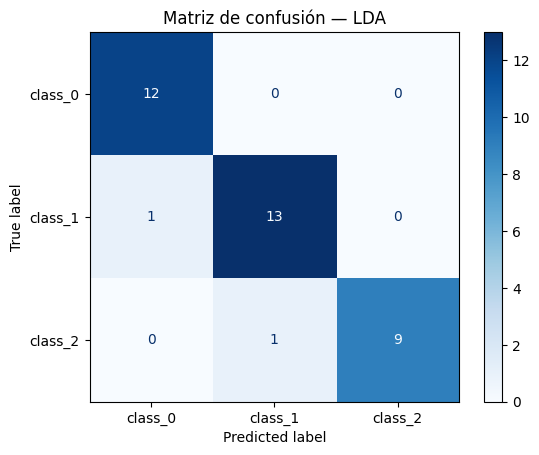

In [ ]:
# Matriz de confusión de LDA
matriz_lda = confusion_matrix(y_test, pred_lda)

disp_lda = ConfusionMatrixDisplay(
    confusion_matrix=matriz_lda,
    display_labels=wine.target_names
)

disp_lda.plot(cmap='Blues', values_format='d')
plt.title('Matriz de confusión — LDA')
plt.show()


**Interpretación de LDA:** la matriz de confusión permite identificar los aciertos y errores en cada cultivar. Un valor alto de `accuracy` indica buen rendimiento global, mientras que las métricas macro permiten comprobar que el desempeño no depende únicamente de la clase más frecuente. Los errores fuera de la diagonal representan vinos asignados a un cultivar distinto del real. La calidad de la clasificación sugiere que una estructura lineal puede capturar una parte importante de la separación entre las clases.


## 6. Implementación de QDA

Se utiliza `QuadraticDiscriminantAnalysis` con los siguientes parámetros:

- `priors=None`: las probabilidades previas se estiman con las frecuencias del entrenamiento.
- `reg_param=0.0`: no se regularizan las matrices de covarianza; se mantiene el comportamiento original del modelo.
- `store_covariance=True`: guarda una matriz de covarianza para cada clase.
- `tol=1e-4`: tolerancia utilizada para detectar posibles problemas de rango en la descomposición de las covarianzas.

QDA estima una matriz de covarianza distinta para cada clase. Debido a que el término cuadrático no se cancela al comparar clases, las fronteras de decisión pueden ser curvas.


In [ ]:
# Crear el modelo QDA
modelo_qda = QuadraticDiscriminantAnalysis(
    priors=None,
    reg_param=0.0,
    store_covariance=True,
    tol=1e-4
)

# Entrenar y evaluar
pred_qda, resultados_qda = evaluar_modelo(
    'QDA',
    modelo_qda,
    X_train,
    X_test,
    y_train,
    y_test
)

print('Métricas de QDA:')
display(pd.DataFrame([resultados_qda]).set_index('Modelo'))

print('\nReporte de clasificación de QDA:')
print(classification_report(
    y_test,
    pred_qda,
    target_names=wine.target_names,
    zero_division=0
))


Métricas de QDA:


,Accuracy,Precision_macro,Recall_macro,F1_macro,Tiempo_entrenamiento_s
Modelo,,,,,
QDA,1.0,1.0,1.0,1.0,0.0096



Reporte de clasificación de QDA:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



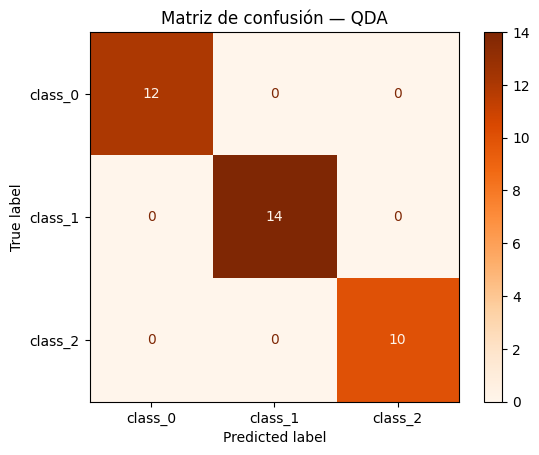

In [ ]:
# Matriz de confusión de QDA
matriz_qda = confusion_matrix(y_test, pred_qda)

disp_qda = ConfusionMatrixDisplay(
    confusion_matrix=matriz_qda,
    display_labels=wine.target_names
)

disp_qda.plot(cmap='Oranges', values_format='d')
plt.title('Matriz de confusión — QDA')
plt.show()


**Interpretación de QDA:** QDA tiene mayor flexibilidad que LDA porque permite que la dispersión y las correlaciones sean diferentes en cada clase. Esa flexibilidad puede mejorar la clasificación cuando los cultivares poseen estructuras de covarianza distintas. Sin embargo, QDA estima más parámetros y puede ser menos estable cuando hay pocas observaciones en comparación con el número de variables.


## 7. Comparación de modelos

In [ ]:
# Construir una tabla comparativa
comparacion = pd.DataFrame([resultados_lda, resultados_qda]).set_index('Modelo')
comparacion = comparacion.sort_values('F1_macro', ascending=False)

display(comparacion)

# Identificar el mejor modelo según F1 macro
mejor_modelo = comparacion['F1_macro'].idxmax()
print('Mejor modelo según F1 macro:', mejor_modelo)


,Accuracy,Precision_macro,Recall_macro,F1_macro,Tiempo_entrenamiento_s
Modelo,,,,,
QDA,1.0000,1.0000,1.0000,1.0000,0.0096
LDA,0.9444,0.9505,0.9429,0.9453,0.0373


Mejor modelo según F1 macro: QDA


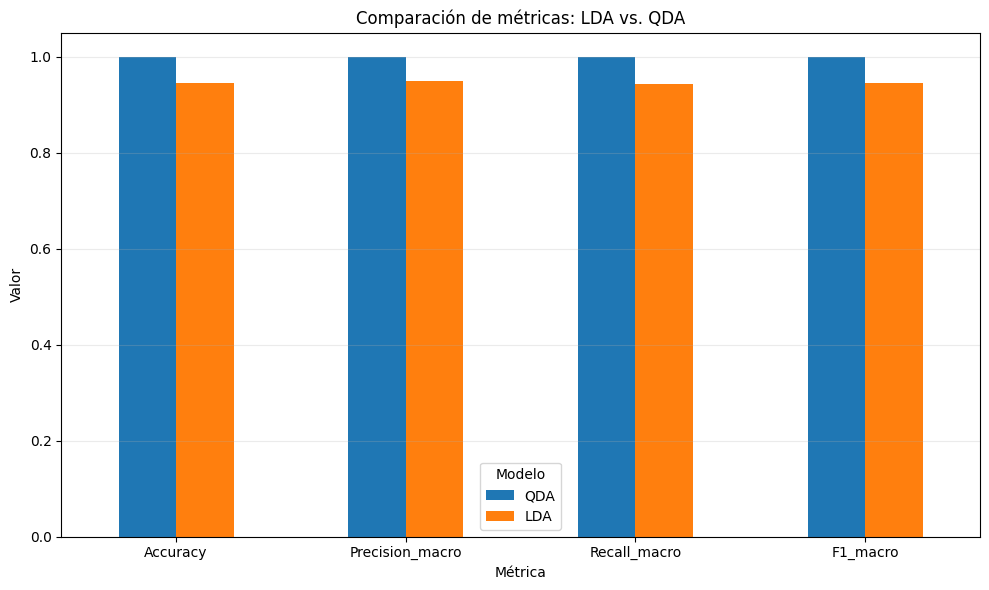

In [ ]:
# Comparación gráfica de las métricas principales
metricas = ['Accuracy', 'Precision_macro', 'Recall_macro', 'F1_macro']

ax = comparacion[metricas].T.plot(
    kind='bar',
    figsize=(10, 6),
    ylim=(0, 1.05)
)

ax.set_title('Comparación de métricas: LDA vs. QDA')
ax.set_xlabel('Métrica')
ax.set_ylabel('Valor')
ax.legend(title='Modelo')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


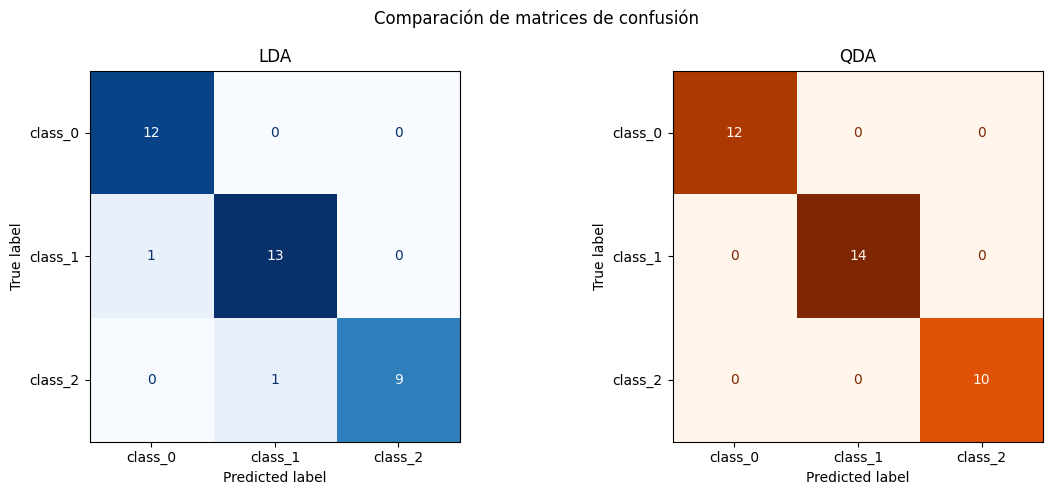

In [ ]:
# Comparar las matrices de confusión en una sola figura
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix=matriz_lda,
    display_labels=wine.target_names
).plot(ax=axes[0], cmap='Blues', values_format='d', colorbar=False)
axes[0].set_title('LDA')

ConfusionMatrixDisplay(
    confusion_matrix=matriz_qda,
    display_labels=wine.target_names
).plot(ax=axes[1], cmap='Oranges', values_format='d', colorbar=False)
axes[1].set_title('QDA')

plt.suptitle('Comparación de matrices de confusión')
plt.tight_layout()
plt.show()


### Análisis comparativo

- **Desempeño predictivo:** la tabla muestra cuál modelo obtuvo mayor `accuracy`, precisión, recall y F1 macro en el mismo conjunto de prueba.
- **Matrices de confusión:** el mejor modelo será aquel que concentre más observaciones en la diagonal principal y reduzca confusiones entre cultivares.
- **Flexibilidad:** LDA utiliza una covarianza común y genera una frontera más simple; QDA estima una covarianza por clase y admite fronteras curvas.
- **Complejidad:** QDA requiere estimar más parámetros, por lo que necesita más observaciones por clase para obtener covarianzas estables.
- **Tiempo de entrenamiento:** en un dataset pequeño ambos modelos son muy rápidos; la diferencia temporal observada debe interpretarse con cautela porque puede variar entre ejecuciones.

La selección final no debe basarse solo en la métrica más alta. También debe considerar estabilidad, interpretabilidad, tamaño muestral y plausibilidad de los supuestos estadísticos.


## 8. Fronteras de decisión con dos variables

Para representar gráficamente las fronteras se utilizarán únicamente `alcohol` e `intensidad del color`. Los modelos de esta sección se entrenan de nuevo con esas dos variables, porque una frontera bidimensional no puede mostrar directamente las 13 dimensiones del modelo principal.

La comparación gráfica permite observar la diferencia estructural esperada:

- LDA produce regiones separadas por líneas rectas.
- QDA puede producir regiones curvas porque utiliza una covarianza diferente en cada clase.


In [ ]:
# Seleccionar dos variables para representar las fronteras
variables_2d = ['alcohol', 'color_intensity']
X_2d = X[variables_2d]

# Realizar una separación reproducible y estratificada
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Entrenar versiones bidimensionales de LDA y QDA
lda_2d = LinearDiscriminantAnalysis(solver='svd')
qda_2d = QuadraticDiscriminantAnalysis(reg_param=0.0)

lda_2d.fit(X_train_2d, y_train_2d)
qda_2d.fit(X_train_2d, y_train_2d)

print('Accuracy LDA con dos variables:', round(lda_2d.score(X_test_2d, y_test_2d), 4))
print('Accuracy QDA con dos variables:', round(qda_2d.score(X_test_2d, y_test_2d), 4))


Accuracy LDA con dos variables: 0.8333
Accuracy QDA con dos variables: 0.8056


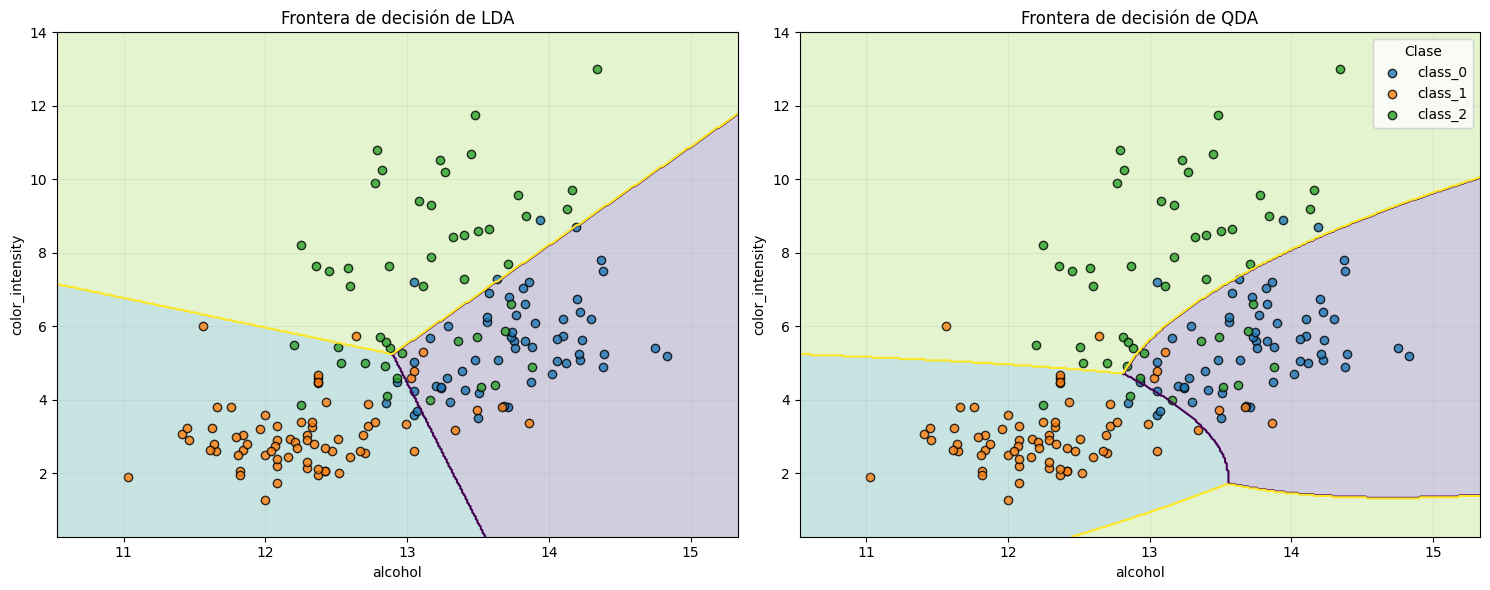

In [ ]:
def graficar_frontera(ax, modelo, titulo, X_datos, y_datos):
    # Grafica regiones y fronteras de decisión para un modelo bidimensional.

    # Límites del plano con un margen adicional
    x_min = X_datos.iloc[:, 0].min() - 0.5
    x_max = X_datos.iloc[:, 0].max() + 0.5
    y_min = X_datos.iloc[:, 1].min() - 1.0
    y_max = X_datos.iloc[:, 1].max() + 1.0

    # Construir una malla de puntos
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    # Predecir la clase de cada punto de la malla
    malla = pd.DataFrame(
        np.c_[xx.ravel(), yy.ravel()],
        columns=X_datos.columns
    )
    zz = modelo.predict(malla).reshape(xx.shape)

    # Mostrar regiones de decisión
    ax.contourf(xx, yy, zz, alpha=0.25, levels=np.arange(-0.5, 3, 1))
    ax.contour(xx, yy, zz, levels=[0.5, 1.5], linewidths=1.5)

    # Mostrar las observaciones reales
    for clase, nombre in enumerate(wine.target_names):
        mascara = y_datos == clase
        ax.scatter(
            X_datos.loc[mascara, variables_2d[0]],
            X_datos.loc[mascara, variables_2d[1]],
            label=nombre,
            edgecolors='black',
            alpha=0.8
        )

    ax.set_title(titulo)
    ax.set_xlabel(variables_2d[0])
    ax.set_ylabel(variables_2d[1])
    ax.grid(alpha=0.2)


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

graficar_frontera(
    axes[0],
    lda_2d,
    'Frontera de decisión de LDA',
    X_2d,
    y
)

graficar_frontera(
    axes[1],
    qda_2d,
    'Frontera de decisión de QDA',
    X_2d,
    y
)

axes[1].legend(title='Clase', loc='best')
plt.tight_layout()
plt.show()


### Interpretación de las fronteras

En LDA, los límites entre las regiones son líneas rectas debido a que las tres clases tienen la misma matriz de covarianza. Los términos cuadráticos se cancelan al hacer la comparación de las funciones discriminantes, por lo que queda solo una expresión lineal.

Cada clase cuenta con su propia matriz de covarianza en QDA. Dado que los términos cuadráticos no se anulan, la frontera tiene la capacidad de doblarse y adecuarse mejor a conjuntos con dispersión o formas variadas. Aunque esa habilidad puede disminuir algunos errores, también aumenta la posibilidad de ajustar las características específicas del conjunto de entrenamiento.

No se puede comparar la precisión de los modelos bidimensionales con la del modelo de 13 variables como si fueran el mismo experimento. La representación en dos dimensiones renuncia a información para que la geometría de las decisiones sea visible.


## 9. Conclusiones

1. LDA proporciona una solución sencilla y fácil de interpretar. Cuando se aplica una matriz de covarianza común, se estiman menos parámetros y tiende a ser estable si la cantidad de datos es pequeña en comparación con la cantidad de variables..

2. QDA es más flexible. Al estimar una matriz de covarianza por clase, se pueden describir límites curvos y ajustarse a clases con estructuras dispersas distintas.

3. El desempeño está influenciado por las hipótesis estadísticas. Si las clases presentan covarianzas parecidas, el LDA tiene la capacidad de igualar o sobrepasar al QDA gracias a su menor varianza. QDA tiene la capacidad de aprovechar esa información adicional cuando las covarianzas son diferentes y hay una cantidad adecuada de observaciones.

4. Las métricas tienen que ser analizadas en conjunto. La exactitud refleja el rendimiento general, pero la precisión, el recall y el F1 macro contribuyen a verificar que el modelo opera correctamente en las tres categorías y no solo en la más común.

5. La matriz de confusión posibilita la identificación de los errores. Además de ofrecer una cifra global, enseña cuáles cultivares son los que generan confusiones y simplifica la evaluación del valor práctico del clasificador.

6. Conservará la información original, aunque limitará el control experimental, si se trabaja sin tratamiento. Si las matrices de covarianza experimentan problemas de estabilidad, en otros contextos sería beneficioso examinar la estandarización, la detección de valores atípicos, la regularización y la validación cruzada.

7. Las fronteras en dos dimensiones muestran la diferencia conceptual entre los modelos. LDA produce divisiones rectas, mientras que QDA tiene la capacidad de crear contornos curvos. Sin embargo, esta visualización solo emplea dos variables y no ilustra de manera integral la conducta del modelo adiestrado con las 13 características.


8. Las dos técnicas son utilizables para problemas reales de clasificación multiclase. Cuando las variables son numéricas y hay grupos definidos con antelación, pueden emplearse para análisis químicos, control de calidad, diagnóstico, clasificación de productos y reconocimiento de patrones.
